In [17]:
#  Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [18]:
#  Step 2: Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target # labels

In [19]:
X.shape

(150, 4)

In [20]:
y.shape

(150,)

Shape: (150, 4) → 150 samples (rows), 4 features (columns).
Each row = one flower sample.
Each column = one measurement:

Sepal length (cm)

Sepal width (cm)

Petal length (cm)

Petal width (cm)

In [21]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Shape: (150,) → 150 integers representing the class of each flower.

0 = Setosa

1 = Versicolor

2 = Virginica

In [22]:
# Variance of each feature

print("Variance per feature:\n", X.var())

Variance per feature:
 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


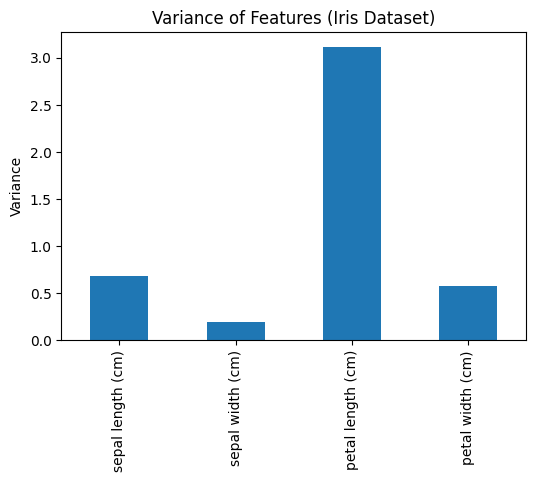

In [23]:
X.var().plot(kind='bar', figsize=(6,4))
plt.title("Variance of Features (Iris Dataset)")
plt.ylabel("Variance")
plt.show()

In [24]:

# Covariance matrix
cov_matrix = np.cov(X.T)
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]


Features with high variance dominate, but PCA finds combinations of features (directions) that capture the most overall variance.

Instead of looking at individual variances, PCA checks how features vary together → new axes.

Example: in a 2D correlated dataset, neither x nor y has max variance alone, but their linear combination (PC1) does.

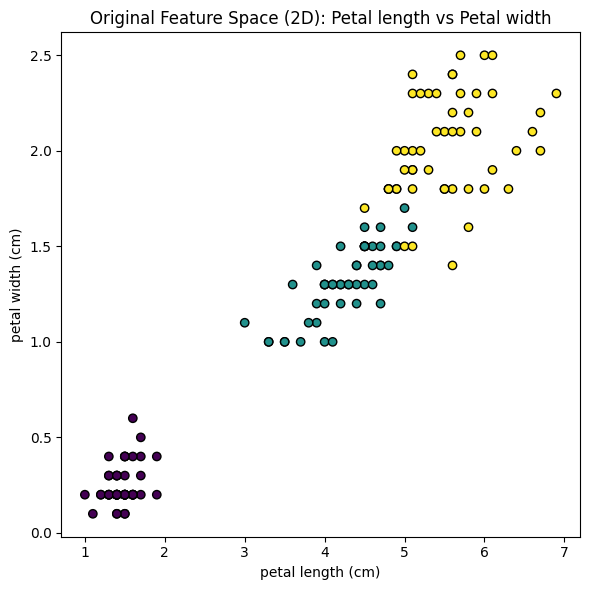

In [25]:
cols = ["petal length (cm)", "petal width (cm)"]
X2 = X[cols].values

# Original 2D scatter
plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=y, edgecolors='k')
plt.xlabel(cols[0])
plt.ylabel(cols[1])
plt.title("Original Feature Space (2D): Petal length vs Petal width")
plt.tight_layout()
plt.show()

In [30]:
pca2 = PCA(n_components=2).fit(X2)

mean_vec = X2.mean(axis=0)
components = pca2.components_          # shape (2,2), unit vectors for PCs
eigvals = pca2.explained_variance_     # variance along each PC



In [28]:
mean_vec

array([3.758     , 1.19933333])

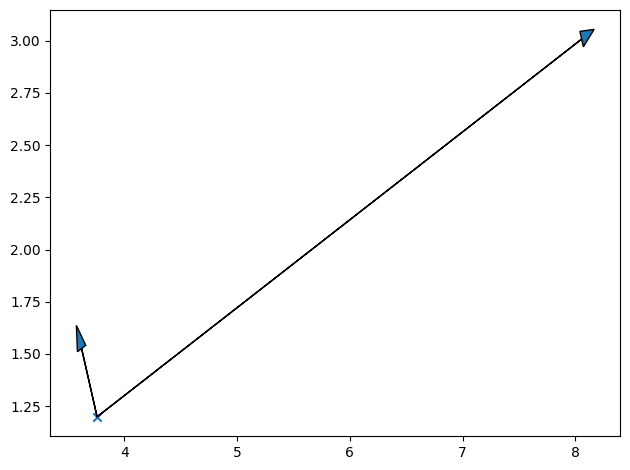

In [27]:
plt.scatter(mean_vec[0], mean_vec[1], marker='x')

# Arrow length proportional to sqrt(variance) for visibility
scales = np.sqrt(eigvals)
for i in range(2):
    vec = components[i] * scales[i] * 2.5  # scale factor for visibility
    plt.arrow(mean_vec[0], mean_vec[1], vec[0], vec[1],
              head_width=0.08, length_includes_head=True)

plt.tight_layout()
plt.show()


[0.99025066 0.00974934]


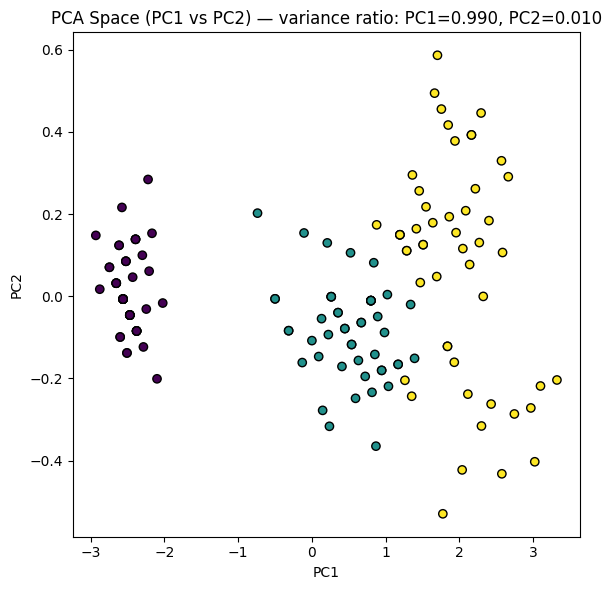

In [32]:
# 5) PCA transform (PC1 vs PC2) with variance ratios
# -----------------------------
X2_pca = pca2.transform(X2)
expl = pca2.explained_variance_ratio_
print(expl)

plt.figure(figsize=(6,6))
plt.scatter(X2_pca[:,0], X2_pca[:,1], c=y, edgecolors='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA Space (PC1 vs PC2) — variance ratio: PC1={expl[0]:.3f}, PC2={expl[1]:.3f}")
plt.tight_layout()
plt.show()

In [33]:
pca_full = PCA().fit(X)  # sklearn centers internally
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

print("\n=== Explained variance ratio (all 4 features) ===")
print(evr)
print("Cumulative:", cum_evr)





=== Explained variance ratio (all 4 features) ===
[0.92461872 0.05306648 0.01710261 0.00521218]
Cumulative: [0.92461872 0.97768521 0.99478782 1.        ]


Variance Explained in PCA

PCA works by projecting data onto new axes (principal components, PCs) that capture maximum variance.

Explained variance ratio = fraction of total variance captured by each principal component.

Example:

PC1 explains 40%

PC2 explains 25%

PC3 explains 15%

Cumulative after 3 PCs = 80% variance captured.

👉 This tells you how much information is retained when you use the first k components instead of all features.

Elbow Plot

Plot cumulative explained variance (%) vs number of components.

The curve rises steeply at first, then flattens → looks like an “elbow”.

The elbow point suggests a good tradeoff between dimensionality reduction and information retention.

Example:
If the curve flattens after 10 PCs (say, 90% variance explained), you may keep those 10 and discard the rest.

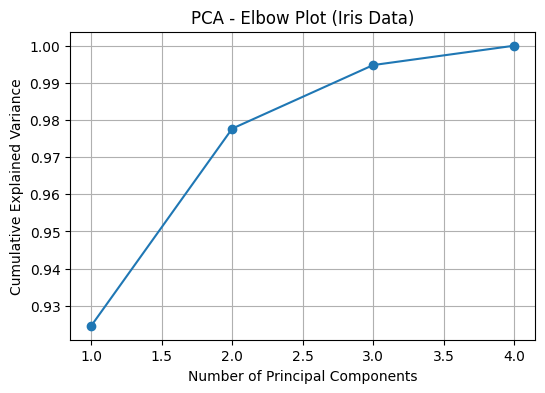

In [34]:
#  Step 5: Elbow Plot (Cumulative Variance)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_evr)+1), cum_evr, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Elbow Plot (Iris Data)")
plt.grid(True)
plt.show()


Elbow Plot showing how many PCs explain most variance.

For Iris, usually first 2 PCs explain ~95% variance.

## Intuition: VIF

Variance Inflamation Factor (VIF) measures how much the variance of a regression coefficient is inflated due to multicollinearity (feature collinearity).

- Think of each feature as a **vector** $\(x_j \in \mathbb{R}^n\$) where **\(n\)** is the number of samples (rows).
- If a feature can be **well reconstructed from the others** (i.e., it lies almost in their **span** \( \mathrm{span}(X_{-j}) \)), it is **redundant/collinear**.
- **Variance Inflation Factor (VIF)** for feature \(j\) measures **how redundant** \(x_j\) is with respect to the rest:
  - **VIF ≈ 1** → the feature carries **unique** information (low redundancy).
  - **Large VIF** → the feature is **mostly overlapping** with others (severe collinearity).



In [35]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Add intercept (constant) so VIF uses R^2 with intercept
X_const = sm.add_constant(X)

vif_rows = []
for i, col in enumerate(X_const.columns):
    if col == "const":
        continue
    vif = variance_inflation_factor(X_const.values, i)
    vif_rows.append({"feature": col, "VIF": vif, "tolerance": 1.0 / vif})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_df)

             feature        VIF  tolerance
0  petal length (cm)  31.261498   0.031988
1   petal width (cm)  16.090175   0.062150
2  sepal length (cm)   7.072722   0.141388
3   sepal width (cm)   2.100872   0.475993




before: 10 11 12 13 14

after: 10 100 50 200 250

# When to Reduce Dimensions with PCA

## Use PCA when…
- **Features are highly correlated / redundant.**  
  *Signs:* many \|r\| > **0.8** in the correlation matrix; multicollinearity warnings (high **VIFs**).
- You need **visualization** of high-D data in **2D/3D** to spot clusters, outliers, or trends.
- You want to **denoise** (retain signal, drop low-variance directions) and **reduce overfitting**.
- **p is large relative to n** (p ≫ n) and models overfit or train slowly.
- You need **faster training/inference** or **lower storage/communication** cost.
- Downstream model benefits from **orthogonal inputs** (e.g., linear/logistic regression becomes more stable).

---

## Avoid (or be cautious) when…
- **Interpretability matters.** PCs are linear mixtures; you lose “feature meaning.”
- Data are **discrete/categorical or very sparse**. Prefer one-hot + **TruncatedSVD/LSA** for sparse text, not PCA.
- **Nonlinear structure dominates.** Use **Kernel PCA**.
- **Class separation ≠ variance direction.** PCA is unsupervised; high variance ≠ best for prediction.
- **Heavy outliers / non-Gaussian scales.** Use robust scaling or **Robust PCA** variants first.
- **Dimensionality is already small** (≤ 5–10) and models perform well.

---

##  Quick decision checklist
- **Standardize** features (zero mean, unit variance).  
- Inspect **correlation matrix / VIFs**; if many strong correlations → consider PCA.  
- Fit PCA on **train only**; check `explained_variance_ratio_` and **cumulative**.  
  - Rule of thumb: keep *k* where cumulative ≥ **90–95%** (domain-dependent).  
- **Compare** baseline vs PCA pipeline via cross-validation.  
  - If accuracy/F1 is same or better **and** you gain speed/robustness → keep PCA.  
- If interpretability needed, report **PC loadings** or consider **Sparse PCA**.

---



